# Monte Carlo Methods: Model-Free Learning

**Series:** RL from scratch · Model-Free Learning · Part 1  

In this notebook I move from model-based to model-free learning. Instead of using the MDP to compute values, the agent plays lots of games, explores and exploits with some probability, and averages the returns it gets to estimate the Q values. Then I make it online, first with a running average and then with a learning rate, which sets things up for TD learning next.

**Contents**
1. Why model-free?
2. Setup
3. Sampling trajectories (ε-greedy)
4. Computing returns
5. Monte Carlo estimation of Q
6. Policy improvement
7. Monte Carlo policy iteration
8. Testing the policy
9. Online Monte Carlo (running mean)
10. Adding a learning rate
11. Summary: DP vs Monte Carlo

## 1. Why model-free?

Policy and value iteration need the full model of the environment, i.e. the transition probabilities:

$$
v_\pi(s) = \sum_a \pi(a \mid s) \sum_{s', r} \underbrace{p(s', r \mid s, a)}_{\text{needs the model}} \big[r + \gamma\, v_\pi(s')\big]
$$

In most real problems, we don't have $p(s', r \mid s, a)$. Monte Carlo gets around this by **playing games** and **averaging the returns**:

$$
q_\pi(s, a) = \mathbb{E}_\pi\big[G_t \mid S_t = s, A_t = a\big] \;\approx\; \frac{1}{N(s,a)} \sum_{i=1}^{N(s,a)} G_i(s, a)
$$

In policy and value iteration, FrozenLake handed us the whole MDP: for every state and every action, where I could end up, with what probability, and what reward I'd get. That made it possible to just **compute** the values.

But in most real problems nobody gives us this. A robot doesn't know the exact probability of slipping on every surface, and a game-playing agent doesn't get a table of every possible outcome. Without $p(s', r \mid s, a)$, policy and value iteration simply don't work anymore.

So instead of computing, the agent has to **learn by interacting**: play the game, see what happens, and learn from that experience. That's what model-free means.

The Monte Carlo idea is basically this: the value is the **expected** return, and an expectation can be estimated by **averaging lots of samples**. So I play lots of games, and for every state-action pair, I average the returns that followed it. The more games I play, the closer the average gets to the true value (law of large numbers).

### Why Q and not V?

With only V, to improve the policy I'd need to look one step ahead and compare actions, and for that I need $p(s' \mid s, a)$, i.e. the model again:

$$
\pi'(s) = \arg\max_a \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, V(s')\big]
$$

With Q, the action is already part of the value, so improving the policy is just $\arg\max_a Q(s, a)$, no model needed. That's why model-free methods estimate Q directly.

## 2. Setup

Slippery FrozenLake 4×4: the intended move happens only 1/3 of the time, otherwise the agent slides sideways.

- 16 states (0 to 15), start at 0 (top-left), goal at 15 (bottom-right), holes at 5, 7, 11, 12.
- 4 actions: 0 = Left, 1 = Down, 2 = Right, 3 = Up.
- Reward 1 for reaching the goal, 0 everywhere else. Falling into a hole or reaching the goal ends the game.
- Slippery means I pick a direction but only move that way 1/3 of the time; the other 2/3 I slide to one of the two perpendicular directions.

The big difference from the model-based notebooks: I'm **not** going to touch `env.unwrapped.P` at all. The agent only gets to use `env.reset()` and `env.step()`, exactly like it would in a real environment.

In [1]:
# !pip install gymnasium   # uncomment on Colab

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

np.random.seed(0)

In [2]:
# create slippery FrozenLake env
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
env.reset(seed=0); env.action_space.seed(0)

# print number of states and actions
print("States:", env.observation_space.n, "| Actions:", env.action_space.n)

States: 16 | Actions: 4


### Helpers (not the focus)

Plotting utilities so the focus stays on the algorithm. Run this cell and move on.

In [3]:
ARROWS = ["←", "↓", "→", "↑"]

def show_policy(policy, Q=None, env=None, title="Policy"):
    """Draw the grid with the policy as arrows; colour = max_a Q(s,a) if Q is given."""
    desc = env.unwrapped.desc.astype(str)
    n = desc.shape[0]
    fig, ax = plt.subplots(figsize=(4, 4))
    values = np.zeros((n, n)) if Q is None else Q.max(axis=1).reshape(n, n)
    ax.imshow(values, cmap="viridis", vmin=0, vmax=max(values.max(), 1e-8))
    for s in range(n * n):
        r, c = divmod(s, n)
        cell = desc[r, c]
        if cell == "H":
            ax.add_patch(plt.Rectangle((c - .5, r - .5), 1, 1, color="black"))
            ax.text(c, r, "H", ha="center", va="center", color="red", fontsize=14)
        elif cell == "G":
            ax.text(c, r, "G", ha="center", va="center", color="gold", fontsize=16, weight="bold")
        else:
            ax.text(c, r, ARROWS[policy[s]], ha="center", va="center", color="white", fontsize=18)
            if Q is not None:
                ax.text(c, r + .32, f"{Q[s].max():.2f}", ha="center", va="center", color="white", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    plt.show()

def plot_curve(y, title="", xlabel="", ylabel=""):
    """Simple line plot."""
    plt.figure(figsize=(6, 3)); plt.plot(y)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.grid(alpha=.3); plt.show()

## 3. Sampling trajectories (ε-greedy)

A trajectory is one full game played with the current policy:

$$
S_0, A_0, R_1, S_1, A_1, R_2, \dots, S_{T-1}, A_{T-1}, R_T
$$

To keep exploring, actions are picked **ε-greedily**: random with probability ε, otherwise the policy's action:

$$
\pi_\varepsilon(a \mid s) =
\begin{cases}
1 - \varepsilon + \dfrac{\varepsilon}{|\mathcal{A}|} & \text{if } a = \pi(s) \\[2mm]
\dfrac{\varepsilon}{|\mathcal{A}|} & \text{otherwise}
\end{cases}
$$

(The $\frac{\varepsilon}{|\mathcal{A}|}$ on the first line is there because the random action can also happen to be the policy's action.)

Since I can't compute anything from the model anymore, the only way to learn the value of an action is to **actually try it**. That creates a trade-off:
- **Exploit:** take the action I currently think is best, to collect reward.
- **Explore:** sometimes try something else, because my current estimates might be wrong and a better action might be hiding there.

ε-greedy is the simplest way to mix the two: most of the time follow the policy, but with probability ε pick a random action.

**What goes wrong with ε = 0:** the agent only ever takes the policy's actions, so the other actions at each state never get tried and their Q values stay at 0 forever. If the starting policy is bad, the agent can never find out there's something better. On FrozenLake it might never even reach the goal once, so every Q value stays 0 and nothing is learned.

In [4]:
def sample_trajectory(pi, env, max_steps=50, epsilon=0.1):
    # empty list to store experience tuples
    trajectory = []

    # reset env → start state
    state, _ = env.reset()

    # loop until episode ends or max_steps reached
    for _ in range(max_steps):
        # ε-greedy: random action w.p. ε, else pi[state]
        if np.random.rand()<epsilon:
            action = env.action_space.sample()
        else:
            action = int(pi[state])

        # take a step in the env
        next_state, reward, truncated, terminated, _ = env.step(action) 

        # store (state, action, reward, next_state, done)
        trajectory.append((state, action, reward, next_state, terminated))
        # move to next state
        if terminated or truncated:
            break
        state = next_state


    # return the trajectory
    return trajectory

In [5]:
# random starting policy (one action per state)
policy = np.random.randint(0, env.action_space.n, size=env.observation_space.n)

# sample one trajectory and print it
trajectory = sample_trajectory(policy, env)
for step in trajectory:
    print(step)

(0, 0, 0, 0, False)
(0, 0, 0, 0, False)
(0, 0, 0, 4, False)
(4, 3, 0, 4, False)
(4, 3, 0, 0, False)
(0, 0, 0, 4, False)
(4, np.int64(3), 0, 0, False)
(0, np.int64(2), 0, 0, False)
(0, np.int64(2), 0, 0, False)
(0, 0, 0, 0, False)
(0, 0, 0, 4, False)
(4, 3, 0, 5, False)


**What I see:** each tuple is (state, action, reward, next state, game over?). With a random policy the game is usually short: the agent slides around for a few steps and falls into a hole with reward 0. Reaching the goal is rare, which is exactly why we need lots of games and some exploration.

## 4. Computing returns

The return from step $t$ is the discounted sum of future rewards:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}
$$

It's recursive, so it's easiest to compute **backwards** from the end of the game:

$$
G_t = R_{t+1} + \gamma\, G_{t+1}, \qquad G_T = 0
$$

Example with 3 steps: $G_2 = R_3$, then $G_1 = R_2 + \gamma G_2$, then $G_0 = R_1 + \gamma G_1$.

**First-visit vs every-visit:** if a pair $(s, a)$ shows up more than once in a game, first-visit MC only uses the return from its first occurrence; every-visit MC uses all of them.

**Why backwards:** if I go forwards, every $G_t$ needs all the rewards after it, so I'd be re-adding the same rewards again and again. Going backwards, each return is just the reward at that step + γ × the return I already computed for the next step. One pass, and every step's return is done.

**Why first-visit (and how the code gets it for free):** on the slippery lake the agent can come back to the same state and take the same action several times in one game. First-visit MC only counts the return from the first time. Both versions converge to the right values; first-visit is just the simpler one to reason about.

The neat trick: when I walk backwards and store $G$ in a dictionary keyed by $(s, a)$, a later (in time) visit gets written first and then **overwritten** by the earlier visit. So once I reach the start of the game, each $(s, a)$ holds the return from its first visit, automatically.

In [6]:
def compute_returns(trajectory, gamma=0.99):
    # dict: (state, action) → G for its first visit
    returns = {}

    # running return, starts at 0
    G = 0 

    # loop over the trajectory in reverse
    for step in reversed(trajectory):
        # unpack state, action, reward
        state, action, reward, _, _ = step

        # G = reward + gamma * G
        G = reward + gamma * G

        # store G for (state, action) (backwards overwrite → first visit wins)
        returns[(state, action)] = G

    # return the dict
    return returns

In [7]:
# sanity check: 3-step game, reward 1 only at the end, gamma = 0.9
toy = [(0, 1, 0.0, 4, False), (4, 2, 0.0, 5, False), (5, 1, 1.0, 9, True)]
out = compute_returns(toy, gamma=0.9)
assert np.isclose(out[(5, 1)], 1.0) and np.isclose(out[(4, 2)], 0.9) and np.isclose(out[(0, 1)], 0.81), out
print("compute_returns ✓", out)

compute_returns ✓ {(5, 1): 1.0, (4, 2): 0.9, (0, 1): 0.81}


## 5. Monte Carlo estimation of Q

Play many games with the same policy, collect the returns that followed each $(s, a)$, and average them:

$$
Q(s, a) = \frac{1}{N(s,a)} \sum_{i=1}^{N(s,a)} G_i(s, a)
$$

By the law of large numbers, $Q(s,a) \to q_\pi(s,a)$ as $N(s,a) \to \infty$.

This is **policy evaluation**, the same job as in policy iteration, but from samples instead of the Bellman equation. In policy iteration I computed the expected return exactly using the model. Here I estimate the same expectation by playing lots of games and averaging what actually happened.

**Pairs that are never visited** just stay at 0, since I have no returns to average for them. That's another reason exploration matters: without it, many state-action pairs would never get a single sample.

In [8]:
def monte_carlo_estimation(pi, env, gamma=0.99, max_steps=50, num_episodes=5000):
    # Q table of zeros, shape (n_states, n_actions)
    Q = np.zeros((env.observation_space.n, env.action_space.n))

    all_returns = {}

    # repeat for num_episodes
    for _ in range(num_episodes):
        # sample a trajectory with pi
        trajectory = sample_trajectory(pi, env, max_steps)

        # compute first-visit returns
        returns = compute_returns(trajectory, gamma)

        # append each G to its (s, a) list
        for (s,a), G in returns.items():
            if (s,a) in all_returns.keys():
                all_returns[(s,a)].append(G)
            else:
                all_returns[(s,a)] = [G]


    # Q[s, a] = mean of its returns (skip unvisited pairs)
    for (s,a), G_list in all_returns.items():
        Q[s,a] = np.mean(G_list)

    # return Q
    return Q

In [9]:
# estimate Q for the random policy and look at it
Q_random = monte_carlo_estimation(policy, env, num_episodes=2000)
print(Q_random.round(3))

[[0.003 0.    0.003 0.003]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.032 0.019 0.007 0.002]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.475 0.041 0.12  0.   ]
 [0.    0.    0.    0.106]
 [0.49  0.216 0.99  0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.198]
 [0.    0.    0.866 0.98 ]
 [0.    0.    0.    0.   ]]


**What I see:** most values are tiny or exactly 0. With a random policy the agent almost never reaches the goal, so most returns are 0. The few non-zero values are for state-action pairs close to the goal, since those are the only places a random agent occasionally gets lucky. The values are still useful, though: even small differences tell the greedy step which actions are slightly better.

## 6. Policy improvement

Same as in policy iteration: act greedily with respect to the current Q:

$$
\pi'(s) = \arg\max_a Q(s, a)
$$

No model needed here, which is exactly why we estimate Q instead of V.

Same reasoning as the policy improvement theorem from policy iteration: if switching to the best action for one step and then following the old policy is at least as good as the old policy, then following the new policy everywhere is at least as good too. The only difference is that my Q values are now estimates from games, so the improvement is only as good as those estimates.

### Watch out for ties

Early on, lots of Q values are exactly 0 (the agent hasn't reached the goal from there yet), so many states have several actions tied for the best. Plain `np.argmax` always picks the **first** tied action, i.e. Left. So a state with no information gets pushed to Left every round, the agent keeps pressing Left, rarely finds the goal, the Q values stay 0, and it gets stuck there. I actually hit this: one run "converged" to a policy with 0% success.

The fix is to handle ties properly:
- If the current action is already one of the best, **keep it** (no reason to switch, and it lets the policy actually settle).
- Otherwise, pick **randomly** among the tied best actions, so states without information don't all collapse onto Left.

In [10]:
def policy_improvement(Q, old_policy):
    # start from the old policy
    new_policy = old_policy.copy()

    # for each state
    for s in range(len(Q)):
        # all actions tied for the best Q
        best_q = max(Q[s])
        best = [a for a in range(len(Q[s])) if abs(Q[s][a] - best_q) < 1e-9]

        # keep the old action if it's among the best, else pick randomly among the best
        if old_policy[s] not in best:
            new_policy[s] = np.random.choice(best)

    # return new policy
    return new_policy

## 7. Monte Carlo policy iteration

Toggle between evaluation (estimate $Q_\pi$ from games) and improvement (greedy update), just like policy iteration:

$$
\pi_0 \xrightarrow{\text{E}} Q_{\pi_0} \xrightarrow{\text{I}} \pi_1 \xrightarrow{\text{E}} Q_{\pi_1} \xrightarrow{\text{I}} \pi_2 \xrightarrow{\text{E}} \cdots \xrightarrow{\text{I}} \pi_* 
$$

It's the exact same loop as policy iteration from the model-based notebook: estimate the values of the current policy, then improve the policy greedily, and repeat. The only thing that changed is **how** the evaluation step works: playing games and averaging returns instead of iterating the Bellman equation with the model.

**Why this is policy iteration and not value iteration:** value iteration has a max inside every update, i.e. it backs up the value of the **best** next action. Monte Carlo never does that. Its target is the actual return G from a game I played with my current policy, so it estimates the value of **that** policy, not the optimal one directly. (The sample-based version of value iteration is Q-learning, coming up in the TD notebooks.)

**Note:** I toggle here, getting a good estimate of Q first and then updating the policy, but it's also possible to update the policy online after every game. That's still policy iteration in spirit, just with very short evaluation steps.

Since the Q values are estimates from random games, two actions with nearly the same value can swap places from one round to the next just from noise. So the policy might never become exactly stable, which is why I cap the number of rounds.

In [11]:
def monte_carlo_policy_iteration(env, gamma=0.99, max_steps=50, num_episodes=10000,
                                 max_iterations=15, estimator=None):
    # which estimator to use for the evaluation step (default: batch average)
    estimator = estimator or monte_carlo_estimation

    # start with a random policy
    policy = np.random.randint(0, env.action_space.n, size=env.observation_space.n)

    # loop
    for i in range(max_iterations):
        # evaluation: estimate Q for current policy
        Q = estimator(policy, env, gamma, max_steps, num_episodes)

        # improvement: greedy policy from Q
        new_policy = policy_improvement(Q, policy)

        # stop if policy didn't change
        if np.array_equal(new_policy, policy):
            print(f"Policy stable after {i + 1} rounds")
            break
        if i == max_iterations - 1:
            print(f"Stopped after {max_iterations} rounds (policy still flipping between near-equal actions)")

        # update policy
        policy = new_policy

    # return policy, Q
    return policy, Q

Policy stable after 8 rounds


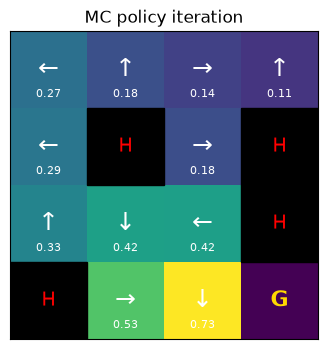

In [12]:
# run MC policy iteration
policy_mc, Q_mc = monte_carlo_policy_iteration(env)

# visualise the learned policy
show_policy(policy_mc, Q_mc, env, title="MC policy iteration")

## 8. Testing the policy

Success rate = fraction of games that reach the goal when following the policy greedily (no exploration).

For reference, the optimal policy on slippery 4×4 succeeds roughly **74%** of the time, so the slipperiness makes 100% impossible.

**Why I turn exploration off when testing:** exploration is for learning. Random actions help me discover better options, but they also make me play worse on purpose. To measure how good the learned policy actually is, I follow it exactly.

In [13]:
def test_policy(policy, env, num_episodes=1000):
    # count successes
    successes = 0

    # loop over episodes
    for _ in range(num_episodes):
        # reset env
        state, _ = env.reset()
        done = False

        # follow policy until done
        while not done:
            state, reward, terminated, truncated, _ = env.step(int(policy[state]))
            done = terminated or truncated

        # success if final reward == 1
        successes += (reward == 1)

    # print and return success rate
    rate = successes / num_episodes
    print(f"Success rate: {rate:.1%}")
    return rate

In [14]:
# test the learned policy
test_policy(policy_mc, env)

Success rate: 71.6%


0.716

**Result:** close to the ~74% the optimal policy gets, without the agent ever looking at the MDP. It learned everything just by playing games. The learned policy also has the same "weird" moves as the optimal one from value iteration, like pointing into walls near the start so a slide can't drop it into a hole.

## 9. Online Monte Carlo (running mean)

Storing every return and averaging at the end wastes memory. The mean can be updated after every new return instead.

**Derivation.** Suppose $Q_k$ is the average of the first $k$ returns, and a new return $G_{k+1}$ arrives:

$$
Q_{k+1} = \frac{1}{k+1} \sum_{i=1}^{k+1} G_i
= \frac{1}{k+1}\left[\sum_{i=1}^{k} G_i + G_{k+1}\right]
$$

Using $\sum_{i=1}^{k} G_i = k\, Q_k$:

$$
Q_{k+1} = \frac{1}{k+1}\big[k\, Q_k + G_{k+1}\big]
= \frac{1}{k+1}\big[(k+1)\, Q_k - Q_k + G_{k+1}\big]
$$

$$
\boxed{\,Q_{k+1} = Q_k + \frac{1}{k+1}\big(G_{k+1} - Q_k\big)\,}
$$

General pattern (shows up everywhere in RL):

$$
\text{NewEstimate} \leftarrow \text{OldEstimate} + \text{StepSize}\,\big[\text{Target} - \text{OldEstimate}\big]
$$

Storing every return and averaging at the end of all the games isn't practical: the lists keep growing, and I can't use the estimate until I'm done. So I go online and keep a **running average** instead, updated after every game.

The key step in the derivation is basically the "add one, subtract one" trick: write $k\,Q_k$ as $(k+1)\,Q_k - Q_k$, so the $(k+1)$ cancels with the $\frac{1}{k+1}$ in front.

**Intuition:** $G_{k+1} - Q_k$ is how far the new return is from my current estimate, i.e. the error. I move my estimate a little bit towards the new return, and the step size $\frac{1}{k+1}$ decides how much.
- After 1 return, I move all the way (step 1): the estimate is just that return.
- After 100 returns, I only move 1% of the way, since one new game shouldn't change an average of 100 games much.

The step shrinks as $k$ grows because each new return is a smaller part of the total. And the result is **exactly** the same as the batch average, just computed without storing anything except $Q$ and a count $N$.

That last boxed form, *old estimate + step size × (target − old estimate)*, is the template for almost every RL update coming next, including TD learning.

In [15]:
def online_monte_carlo_estimation(pi, env, gamma=0.99, max_steps=50, num_episodes=5000):
    # Q table of zeros
    Q = np.zeros((env.observation_space.n, env.action_space.n))

    # visit counts N, same shape as Q
    N = np.zeros_like(Q)

    # repeat for num_episodes
    for _ in range(num_episodes):
        # sample a trajectory
        trajectory = sample_trajectory(pi, env, max_steps)

        # compute first-visit returns
        returns = compute_returns(trajectory, gamma)

        # for each (s, a), G:
        for (s, a), G in returns.items():
            # increment N[s, a]
            N[s, a] += 1

            # Q[s, a] += (G - Q[s, a]) / N[s, a]
            Q[s, a] += (G - Q[s, a]) / N[s, a]

    # return Q
    return Q

In [16]:
# sanity check: running mean == batch mean on random numbers
xs = np.random.rand(1000)
q, n = 0.0, 0
for x in xs:
    n += 1
    q += (x - q) / n
assert np.isclose(q, xs.mean())
print("running mean ✓", q, xs.mean())

running mean ✓ 0.48991880798504284 0.48991880798504345


In [17]:
# MC policy iteration using the online estimator
policy_online, Q_online = monte_carlo_policy_iteration(env, estimator=online_monte_carlo_estimation)

# test it
test_policy(policy_online, env)

Policy stable after 7 rounds
Success rate: 68.9%


0.689

## 10. Adding a learning rate

Replace the $\frac{1}{k+1}$ with a step size $\alpha_t$:

$$
Q_{k+1} = Q_k + \alpha_t\big(G_{k+1} - Q_k\big)
$$

With a constant α, rearrange the update:

$$
Q_{k+1} = Q_k + \alpha\,(G_k - Q_k) = (1-\alpha)\,Q_k + \alpha\,G_k
$$

So each update **keeps (1 − α) of the old estimate** and **adds α of the new return**. Unrolling it from the initial guess $Q_1$:

$$
\begin{aligned}
Q_2 &= (1-\alpha)\,Q_1 + \alpha\,G_1 \\
Q_3 &= (1-\alpha)^2\,Q_1 + \alpha(1-\alpha)\,G_1 + \alpha\,G_2 \\
Q_4 &= (1-\alpha)^3\,Q_1 + \alpha(1-\alpha)^2\,G_1 + \alpha(1-\alpha)\,G_2 + \alpha\,G_3
\end{aligned}
$$

Every new update multiplies everything already inside $Q$ by another $(1-\alpha)$. So after $k$ returns:

$$
Q_{k+1} = (1-\alpha)^k\, Q_1 + \sum_{i=1}^{k} \alpha\,(1-\alpha)^{k-i}\, G_i
$$

The newest return gets weight α, the one before it α(1 − α), then α(1 − α)², and so on (with α = 0.1: 0.1, 0.09, 0.081, …). The weights still add up to 1, so it's still an average, just an **exponential recency-weighted** one: recent games count more, old games fade away. Roughly, it remembers the last $\frac{1}{\alpha}$ games.

Here we use an exponentially decaying schedule:

$$
\alpha_t = \max\big(\alpha_{\min},\; \alpha_0 \cdot d^{\,t}\big)
$$

Most implementations you'll find online use a learning rate $\alpha$ instead of $\frac{1}{k+1}$. Why?

**The running mean treats every return equally**, the first game counts just as much as the latest one. That's perfect when the policy is fixed. But in policy iteration the policy **keeps changing**, and returns from games played with an old, worse policy describe a policy I'm no longer following. They're stale.

**A learning rate gives recent returns more weight.** Unrolling the constant-α update shows each older return gets multiplied by another $(1 - \alpha)$, so old games fade away exponentially. The estimate tracks the **current** policy instead of being dragged down by the past.

**The trade-off:**
- **Big α:** tracks changes quickly, but the estimate is noisy, since it jumps a lot with every game.
- **Small α:** smooth and stable, but slow to react when the policy changes.

The decaying schedule tries to get the best of both: start with a big α to learn fast, then shrink it so the estimate settles down.

In [18]:
def lr_scheduler(start_val, min_val, decay_factor, num_episodes):
    # alpha_t = start_val * decay_factor ** t
    alphas = start_val * decay_factor ** np.arange(num_episodes)

    # clip at min_val
    alphas = np.maximum(alphas, min_val)

    # return list of alphas
    return alphas

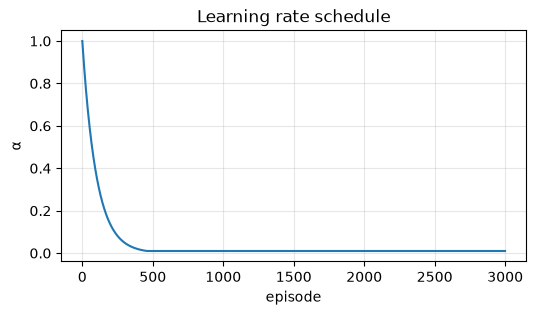

In [19]:
# plot the schedule
plot_curve(lr_scheduler(1.0, 0.01, 0.99, 3000), title="Learning rate schedule", xlabel="episode", ylabel="α")

**What I see:** α starts at 1 (the first return completely replaces the estimate), decays quickly over the first few hundred games, and then sits at the minimum of 0.01 so the estimate keeps adapting slowly instead of freezing.

In [20]:
def online_monte_carlo_estimation_w_lr(pi, env, gamma=0.99, max_steps=50, num_episodes=5000,
                                       lr_start_val=0.8, lr_min_val=0.01, lr_decay_factor=0.99):
    # Q table of zeros
    Q = np.zeros((env.observation_space.n, env.action_space.n))

    # build alpha schedule
    alphas = lr_scheduler(lr_start_val, lr_min_val, lr_decay_factor, num_episodes)

    # for each episode t
    for t in range(num_episodes):
        # sample a trajectory
        trajectory = sample_trajectory(pi, env, max_steps)

        # compute first-visit returns
        returns = compute_returns(trajectory, gamma)

        # Q[s, a] += alpha_t * (G - Q[s, a])
        for (s, a), G in returns.items():
            Q[s, a] += alphas[t] * (G - Q[s, a])

    # return Q
    return Q

Policy stable after 10 rounds
Success rate: 51.7%


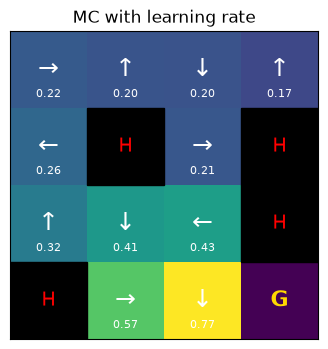

In [21]:
# MC policy iteration using the learning-rate estimator
policy_lr, Q_lr = monte_carlo_policy_iteration(env, estimator=online_monte_carlo_estimation_w_lr)

# test it and visualise
test_policy(policy_lr, env)
show_policy(policy_lr, Q_lr, env, title="MC with learning rate")

### Running mean vs constant learning rate, side by side

To see the difference, I take the policy learned in section 7, play 400 games from the start, and track the estimate of the start state's value two ways: the running mean ($\frac{1}{N}$) and a constant step ($\alpha = 0.05$).

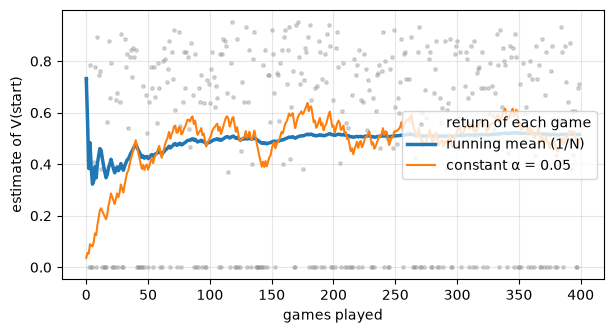

In [22]:
# play 400 games with the policy from section 7 (no exploration), record the return from the start
gamma = 0.99
G_start = []
for _ in range(400):
    traj = sample_trajectory(policy_mc, env, max_steps=100, epsilon=0.0)
    G_start.append(compute_returns(traj, gamma)[(traj[0][0], traj[0][1])])
G_start = np.array(G_start)

# running mean (1/N) vs constant step (alpha = 0.05)
running_mean = np.cumsum(G_start) / np.arange(1, len(G_start) + 1)
ema, q = [], 0.0
for G in G_start:
    q += 0.05 * (G - q)
    ema.append(q)

plt.figure(figsize=(7, 3.5))
plt.scatter(range(len(G_start)), G_start, s=6, alpha=.3, color="gray", label="return of each game")
plt.plot(running_mean, lw=2.5, label="running mean (1/N)")
plt.plot(ema, lw=1.5, label="constant α = 0.05")
plt.xlabel("games played"); plt.ylabel("estimate of V(start)"); plt.legend(loc="center right"); plt.grid(alpha=.3); plt.show()

**What I see:** every single game's return is either 0 (fell into a hole) or something below 1 (reached the goal, discounted by how long it took), so individual returns are super noisy. The running mean starts jumpy but quickly settles on a stable value. The constant-α line keeps wiggling, because it always gives the latest games a fixed weight, but that's also what lets it follow a policy that's still changing.

**Comparison of the three versions (my run):**

| Version | Success rate |
| --- | --- |
| Batch mean | ~72% |
| Running mean | ~69% |
| Learning rate | ~52% |

- **Batch mean and running mean** are the exact same estimate computed two ways, so the small difference between them is just the randomness of the games. Both get close to the ~74% optimum.
- **The learning-rate version came out lower**, and it's worth understanding why. The schedule decays **per game**, so after a few hundred games α is already down at 0.01. State-action pairs that are visited often still get lots of small updates and settle fine. But pairs that are rarely visited only get a handful of tiny updates, so their Q values stay stuck close to 0, and the greedy step makes bad choices in those states.
- So a learning rate isn't automatically better: it needs tuning (start value, decay, minimum). It's the default in the TD methods next because there the policy and estimates change after **every step**, and weighting recent information more becomes essential.

**Experiments to try:** a bigger minimum α (e.g. 0.05), a slower decay (e.g. 0.999), or more exploration (ε = 0.2), and see how the learning-rate version's success rate changes.

## 11. Summary: DP vs Monte Carlo

|  | Policy / Value iteration (DP) | Monte Carlo |
| --- | --- | --- |
| Needs the model $p(s', r \mid s, a)$? | Yes | No, learns from games |
| What it estimates | $V$ (computed exactly) | $Q$ (averaged from samples) |
| Update target | Expected value over all next states, using the model | The actual return $G$ from a game |
| When updates happen | Sweeps over all states | After each full game |
| Bootstraps from its own estimates? | Yes, uses $V(s')$ | No, uses real rewards till the end |
| Bias / variance | No sampling noise (exact model) | Unbiased but high variance (every random step adds up) |

**Key takeaways:**
- Without the model, the agent has to learn by interacting: play games, and average the returns that followed each state-action pair to estimate Q.
- I estimate Q instead of V because improving the policy from Q is just an argmax, no model needed.
- ε-greedy keeps the agent exploring, otherwise unvisited actions stay at 0 forever and better options never get discovered.
- Monte Carlo control is policy iteration with sampled evaluation: estimate Q of the current policy from games, improve greedily, repeat.
- The running average $Q \leftarrow Q + \frac{1}{N}(G - Q)$ gives the exact same estimate without storing any returns. Swapping $\frac{1}{N}$ for α weights recent games more, which helps when the policy keeps changing.

**Limitation → what's next:** G is still the actual sum of rewards till the end of the game, so we have to finish every game before updating anything, and games can be really long. TD learning fixes this by bootstrapping: replacing the rest of the return with the current estimate of the next state's value, so Q can be updated after every single step.